# Confusion Matrices: Pixsplit HGQ-models pre-HLS
Conda environment for this notebook is in `development/plots/environment.yml`

Based on [HLS4ML tutorial plotting.py](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/main/plotting.py)


In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import plotting
# standardize colors
from cycler import cycler 

# Fonts match with latex
matplotlib.rcParams.update({
    'font.family': 'serif',
})

In [2]:
prediction_dir = 'predictions/'

y_true = np.argmax(np.load("processed_data/y_test.npy").astype('float32'), axis=1)
#y_true = np.load("processed_data/y_test.npy")
classes = ["C1", "C2", "C3"]
np.count_nonzero(y_true)

np.int64(275356)

In [3]:
def dut_cm(prediction_path, plotname):
    y_dut = np.argmax(np.load(prediction_path), axis=1)
    cm = confusion_matrix(y_true, y_dut)

    fig, ax = plt.subplots(figsize=(10, 6))
    plotting.plot_confusion_matrix(cm, classes, normalize=True, title=plotname)

    #plt.suptitle(plotname, size = 'xx-large')#, weight = 'bold')
    plt.tight_layout()
    plt.show()

    fig.savefig(f"export/CM_{plotname.lower()}.pdf", format='pdf', bbox_inches="tight")

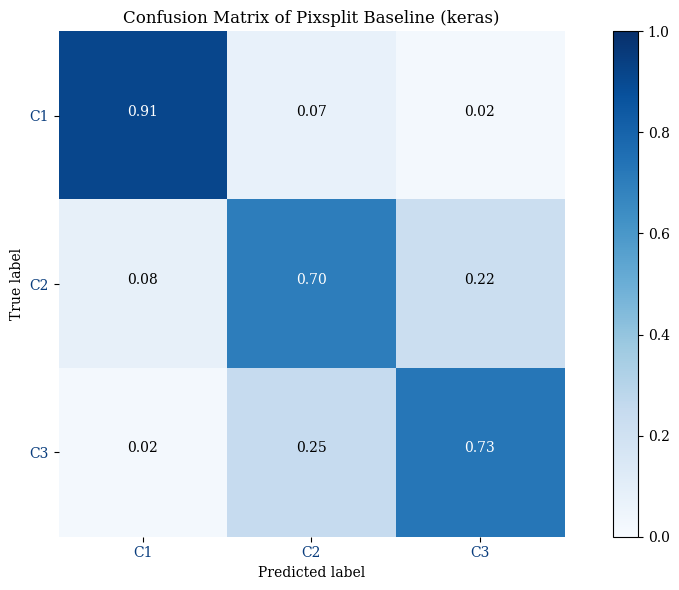

Searching for predictions in predictions/
predictions/y_dut_Training_AdaptiveHP_acc=0.7084_ebops=864_VU_DA_bitfile.npy


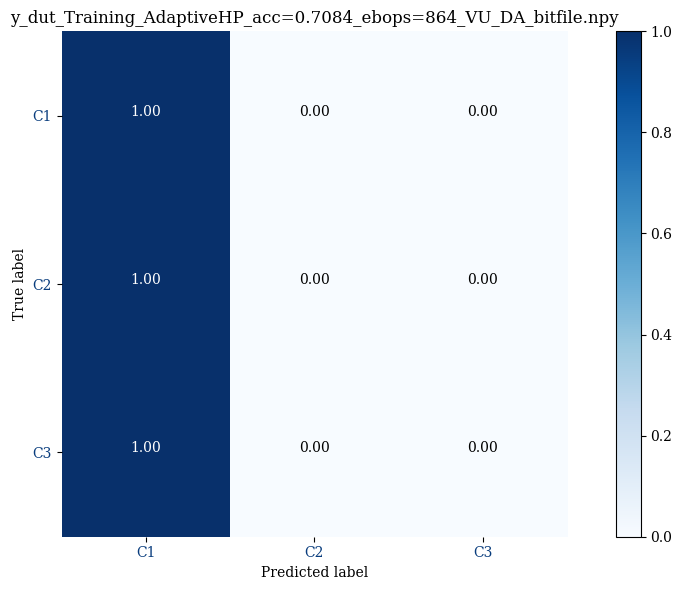

predictions/y_dut_Training_AdaptiveHP_acc=0.7573_ebops=11698_VU_latency_bitfile.npy


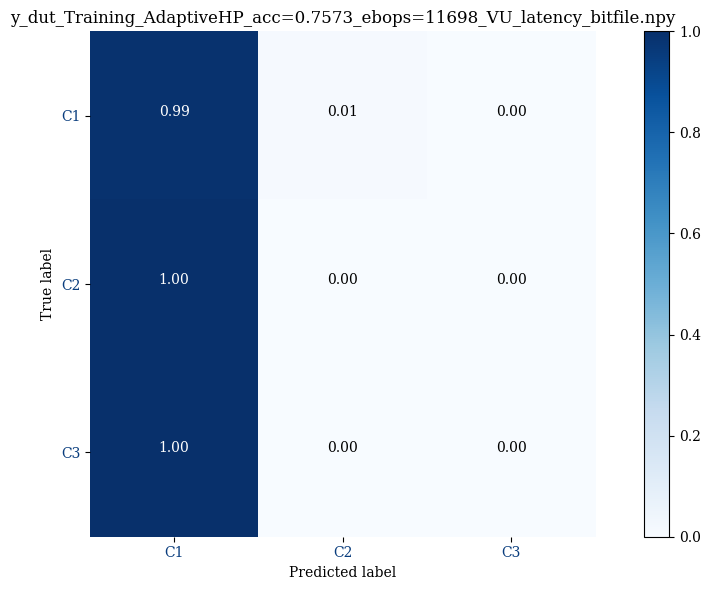

predictions/y_dut_Training_AdaptiveHP_acc=0.7573_ebops=11698_VU_DA_bitfile.npy


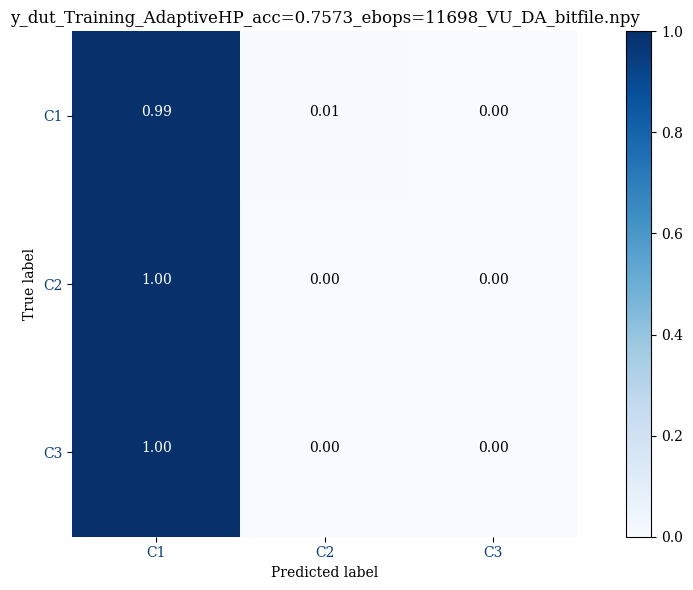

predictions/y_dut_Training_AdaptiveHP_acc=0.7084_ebops=864_VU_latency_bitfile.npy


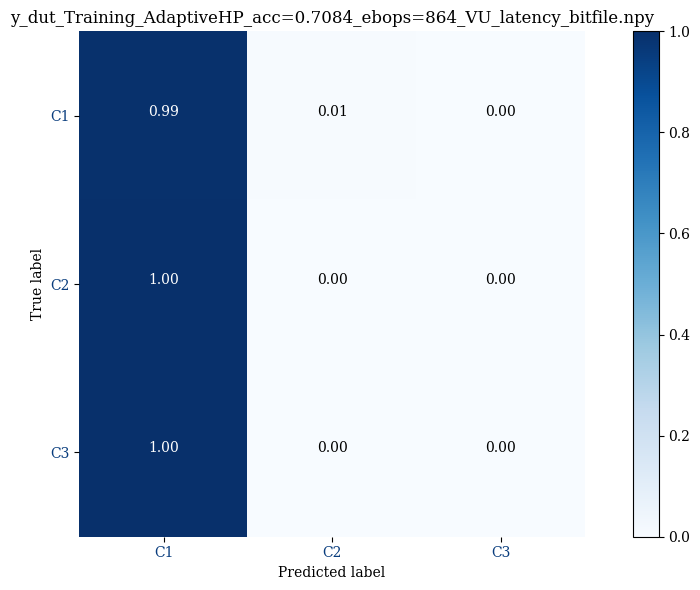

predictions/y_dut_Training_AdaptiveHP_acc=0.7449_ebops=3640_VU_DA_bitfile.npy


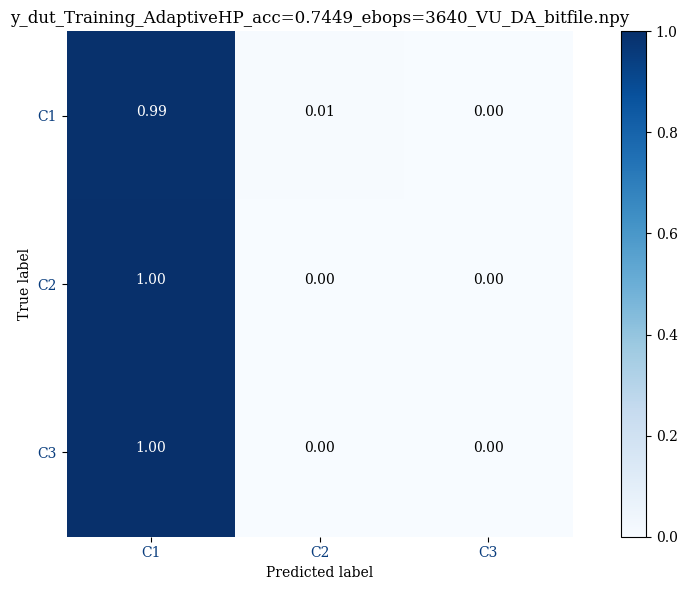

In [4]:
from pathlib import Path

dut_cm('y_baseline.npy','Confusion Matrix of Pixsplit Baseline (keras)')

paths = []

print(f"Searching for predictions in {prediction_dir}")
for prediction_path in Path(prediction_dir).rglob('*.npy'):
    print(prediction_path)
    dut_cm(prediction_path, str(prediction_path.name))
    paths.append(prediction_path)

Simple example of confusion matrix

In [32]:
plotname = "Confusion Matrix of a Jet Tagging Classifier"

#plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.size'] = 11

classes = np.load("../testmodel/classes.npy", allow_pickle=True)
y_true = np.load("../testmodel/y_test.npy")
y_true = np.argmax(y_true, axis=1)
y_keras = np.load("../testmodel/y_keras.npy")
y_keras = np.argmax(y_keras, axis=1)

cm = confusion_matrix(y_true, y_keras)

fig, ax = plt.subplots()
plotting.plot_confusion_matrix(cm, classes, normalize=True, title=plotname)

fig.savefig(f"export/{plotname.lower()}.pdf", format='pdf', bbox_inches="tight")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../testmodel/classes.npy'